# ICB-Sum Pipeline Workflow
**Information Constrained Budgeted Summarization for PDFs**

In [1]:
%load_ext autoreload
%autoreload 2

## Setup & Configuration

In [11]:
from pathlib import Path
import time
import numpy as np
from src.multi_anchor import generate_multi_anchors, MultiAnchorScorer

from src.config import load_config
from src.utils import ensure_dir, stable_id

# Configuration
cfg = load_config("config/default_config.yaml")
pdf_path = Path("/Users/vedumrajkar/Desktop/dpp-retrieval/data/ddpm.pdf").resolve()
query = "Is DDPM sampling a good replacement for current GAN generation stack?"

user_instruction = query

# Setup output directory
run_id = stable_id(pdf_path.name, str(pdf_path.stat().st_size))[:16]
work_dir = ensure_dir(cfg.paths.work_dir / run_id)
out_dir = ensure_dir(work_dir / "results")

print(f"Run ID: {run_id}")
print(f"PDF: {pdf_path.name} ({pdf_path.stat().st_size / 1e6:.1f} MB)")
print(f"Output: {out_dir}")

Run ID: 2de6cebfacc05110
PDF: ddpm.pdf (10.3 MB)
Output: output/2de6cebfacc05110/results


## Stage 1: Anchor Query Generation
*Generate enhanced retrieval query for better relevance*

In [3]:
from src.anchor_summary import generate_anchor_query
from src.openai_client import OpenAIChatClient

retrieval_query = query
anchor_text = None

if cfg.anchor.enabled:
    client = OpenAIChatClient(timeout_s=cfg.extract.timeout_s)
    anchor_text, _anchor_meta = generate_anchor_query(
        client=client,
        model=cfg.openai.model,
        temperature=cfg.openai.temperature,
        query=query,
        user_instruction=user_instruction,
        required_sections=cfg.summarization.required_sections,
        max_chars=cfg.anchor.max_chars,
    )
    retrieval_query = f"{query}\n\n{anchor_text}".strip()
    print(f"Anchor query generated: {len(anchor_text)} chars")
else:
    print("Anchor query disabled")

Anchor query generated: 1384 chars


## Stage 2: PDF Extraction
*Extract layout, text, images, and structure*

In [4]:
from src.layout_aware_extractor import PdfLayoutExtractor

t0 = time.perf_counter()
extractor = PdfLayoutExtractor(cfg)
doc = extractor.extract(pdf_path, out_dir=cfg.paths.work_dir)

print(f"Extracted: {len(doc.pages)} pages, {len(doc.elements)} elements in {time.perf_counter() - t0:.1f}s")

Extracted: 25 pages, 248 elements in 0.0s


## Stage 3: Evidence Unit Construction
*Build semantic units with context and images*

In [5]:
from src.evidence_builder import EvidenceBuilder
from src.cognitive_profiler import TokenCounter

t0 = time.perf_counter()
token_counter = TokenCounter()
builder = EvidenceBuilder(
    max_text_chunk_tokens=cfg.extract.max_text_chunk_tokens,
    caption_search_px=cfg.extract.caption_search_px,
    stopwords=set(),
)
units = builder.build(doc, token_counter=token_counter)

print(f"Built: {len(units)} evidence units in {time.perf_counter() - t0:.1f}s")

Built: 248 evidence units in 0.3s


In [6]:
units

[EvidenceUnit(id='d0ab47a4306ee528', page=1, bbox=(0.0, 0.0, 2550.0, 3300.0), type='figure', retrieval_text='Figure 1: Generated samples on CelebA-HQ 256 × 256 (left) and unconditional CIFAR10 (right)', context_text='Figure 1: Generated samples on CelebA-HQ 256 × 256 (left) and unconditional CIFAR10 (right)', image_paths=[], source_element_ids=['27d32d543f3c7756']),
 EvidenceUnit(id='6db88b3b964305d7', page=1, bbox=(0.0, 0.0, 2550.0, 3300.0), type='heading', retrieval_text='Denoising Diffusion Probabilistic Models', context_text='Denoising Diffusion Probabilistic Models', image_paths=[], source_element_ids=['7f1ca21c1af54964']),
 EvidenceUnit(id='39a5df574ea877a0', page=1, bbox=(0.0, 0.0, 2550.0, 3300.0), type='text', retrieval_text='Jonathan Ho  \nUC Berkeley  \njonathanho@berkeley.edu', context_text='Jonathan Ho  \nUC Berkeley  \njonathanho@berkeley.edu', image_paths=[], source_element_ids=['f4e969a9a5975c6c']),
 EvidenceUnit(id='11b512dfc934b899', page=1, bbox=(0.0, 0.0, 2550.0, 330

## Stage 4: Multimodal Embedding
*Embed text, images, and query*

In [7]:
from src.embedder import MultiModalEmbedder
import torch

def normalize(v):
    return v / (np.linalg.norm(v) + 1e-12)

def build_unit_vectors(units, text_vecs, img_vecs, img_weight, dim):
    """Build unit vectors. With unified embeddings, uses simple averaging."""
    unit_vecs = {}
    zero = np.zeros(dim, dtype=np.float32)
    for u in units:
        text_vec = text_vecs.get(u.id, zero)
        img_vec = img_vecs.get(u.id)
        # Unified embedding space: simple average (already semantically aligned)
        combined = (text_vec + img_vec) / 2.0 if img_vec is not None else text_vec
        unit_vecs[u.id] = normalize(combined)
    return unit_vecs

t0 = time.perf_counter()

# Use SigLIP for unified text-image embeddings
embedder = MultiModalEmbedder(
    backend="hf_siglip",                           # Use HuggingFace SigLIP
    model_name="google/siglip-base-patch16-224",  # UNIFIED MODEL - handles both text & images
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=32,
    dim=0,  # Auto-infer (will be 768 for base model)
)

# Text embeddings - now using SigLIP text encoder
unit_texts = [u.retrieval_text or "" for u in units]
text_res = embedder.embed_text([u.id for u in units], unit_texts)
text_vecs = {i: v.astype(np.float32) for i, v in zip(text_res.ids, text_res.vecs)}

# Image embeddings - now using SigLIP image encoder (same space as text!)
img_units = [(u.id, u.image_paths[0]) for u in units if u.image_paths]
img_vecs = {}
if img_units:
    img_ids, img_paths = zip(*img_units)
    img_res = embedder.embed_images(list(img_ids), list(img_paths))
    img_vecs = {i: v.astype(np.float32) for i, v in zip(img_res.ids, img_res.vecs)}

# Page embeddings - using SigLIP image encoder
page_imgs = [(p.page, p.page_image_path) for p in doc.pages if p.page_image_path]
page_vecs = {}
if page_imgs:
    page_ids, img_paths = zip(*page_imgs)
    page_res = embedder.embed_images([str(i) for i in page_ids], list(img_paths))
    page_vecs = {int(i): v.astype(np.float32) for i, v in zip(page_res.ids, page_res.vecs)}

# Combine and normalize - now using simple averaging for unified space
dim = text_vecs[next(iter(text_vecs))].shape[0]
unit_vecs = build_unit_vectors(units, text_vecs, img_vecs, 1.0, dim)  # img_weight=1.0 (not used)
query_vec = normalize(embedder.embed_query(retrieval_query).astype(np.float32))

print(f"Embedded: {len(unit_vecs)} units, {len(page_vecs)} pages, query in {time.perf_counter() - t0:.1f}s")
print(f"Embedding dimension: {dim} (unified SigLIP space)")

Embedded: 248 units, 25 pages, query in 24.1s
Embedding dimension: 768 (unified SigLIP space)


## Stage 5: Candidate Retrieval
*Retrieve relevant candidates using dense + page-level retrieval*

In [8]:
# Verification: Check unified embedding space
print(f"\n=== Embedding Space Verification ===")
print(f"Text embedding dim: {next(iter(text_vecs.values())).shape}")
print(f"Image embedding dim: {next(iter(img_vecs.values())).shape if img_vecs else 'No images'}")
print(f"Query embedding dim: {query_vec.shape}")

# Check a sample similarity
if text_vecs and img_vecs:
    sample_text_id = next(iter(text_vecs.keys()))
    sample_img_id = next(iter(img_vecs.keys()))
    text_img_sim = float(text_vecs[sample_text_id] @ img_vecs[sample_img_id])
    print(f"Sample text-image similarity: {text_img_sim:.3f}")
    print(f"✓ Embeddings are in unified space (similarity is computable)")


=== Embedding Space Verification ===
Text embedding dim: (768,)
Image embedding dim: (768,)
Query embedding dim: (768,)
Sample text-image similarity: 0.019
✓ Embeddings are in unified space (similarity is computable)


In [13]:
from src.indexing import CombinedRetriever

t0 = time.perf_counter()
retriever = CombinedRetriever(
    units=units,
    unit_vecs=unit_vecs,
    page_vecs=page_vecs,
    rrf_k=cfg.retrieval.rrf_k,
    table_boost=cfg.retrieval.table_boost,
    figure_boost=cfg.retrieval.figure_boost,
    min_table_candidates=cfg.retrieval.min_table_candidates,
    min_figure_candidates=cfg.retrieval.min_figure_candidates,
)

hits, top_pages = retriever.retrieve(
    query_vec=query_vec,
    top_pages=cfg.retrieval.top_pages,
    top_dense=cfg.retrieval.top_units_dense,
)

rel_scores = {h.unit_id: h.score for h in hits}
candidates = [u for u in units if u.id in rel_scores]

print(f"Retrieved: {len(candidates)} candidates from {len(top_pages)} pages in {time.perf_counter() - t0:.1f}s")
print(f"Top score: {max(rel_scores.values()):.3f}")

Retrieved: 248 candidates from 25 pages in 0.0s
Top score: 0.037


## Stage 5.5: Multi-Anchor Scoring (Optional)
*Enhanced scoring with multiple anchor queries*

In [14]:
if cfg.multi_anchor.enabled:
    
    t0 = time.perf_counter()
    client = OpenAIChatClient(timeout_s=cfg.extract.timeout_s)
    anchor_queries = generate_multi_anchors(
        client=client,
        model=cfg.openai.model,
        temperature=cfg.openai.temperature,
        query=query,
        user_instruction=user_instruction,
        anchor_count=cfg.multi_anchor.anchor_count,
        required_sections=cfg.summarization.required_sections,
    )
    
    candidate_ids = {h.unit_id for h in hits}
    candidate_vecs = {u.id: unit_vecs[u.id] for u in units if u.id in candidate_ids}
    
    scorer = MultiAnchorScorer(
        embedder=embedder,
        unit_vecs=candidate_vecs,
        temperature=cfg.multi_anchor.temperature,
    )
    rel_scores = scorer.compute_scores(anchor_queries)
    
    print(f"Multi-anchor scoring: K={len(anchor_queries)}, {len(rel_scores)} candidates")
    print(f"Score range: [{min(rel_scores.values()):.4f}, {max(rel_scores.values()):.4f}]")
    print(f"Time: {time.perf_counter() - t0:.1f}s")

Multi-anchor scoring: K=5, 248 candidates
Score range: [0.0955, 0.7761]
Time: 5.0s


## Stage 6: Budget-Constrained Selection
*Select optimal units within cognitive budget using multiple methods*

In [22]:
from src.cognitive_profiler import SimpleCostProfiler, EmbeddingBasedCostProfiler
from src.optimizer import BudgetedSelector

t0 = time.perf_counter()

# ----------------------------
# Cost profiling (TEXT-ONLY emb mode; images just get a small discount)
# ----------------------------
if cfg.selection.cognitive_cost_mode == "emb":
    profiler = EmbeddingBasedCostProfiler(
        token_counter=token_counter,
        model_name=cfg.selection.cognitive_cost_hf_model,
        device=cfg.selection.cognitive_cost_device,
        # keep these in config if you want; otherwise defaults from class apply
        max_discount_frac=getattr(cfg.selection, "max_discount_frac", 0.50),
        image_cost_multiplier=getattr(cfg.selection, "image_cost_multiplier", 0.85),
        max_length=getattr(cfg.selection, "cognitive_cost_max_length", 512),
    )
    costs = {
        u.id: profiler.cost(u.context_text, u.image_paths, unit_type=u.type).total
        for u in units
    }
else:
    profiler = SimpleCostProfiler(
        token_counter=token_counter,
        alpha_visual=cfg.selection.alpha_visual,
    )
    costs = {u.id: profiler.cost(u.context_text, u.image_paths).total for u in units}

# Optional config values
coverage_weight = getattr(cfg.selection, "coverage_weight", 0.5)
stopwords = set(getattr(cfg.selection, "stopwords", []))

# Selection with multiple methods
selector = BudgetedSelector(
    budget_tokens=cfg.selection.budget_tokens,
    redundancy_beta=cfg.selection.redundancy_beta,
    rel_weight=cfg.selection.rel_weight,
    min_gain=cfg.selection.min_gain,
    coverage_weight=coverage_weight,
    stopwords=stopwords,
)

methods = ["greedy", "topk", "greedy_cov", "cost_norm", "dpp"]
selections: dict[str, list] = {}
budgets_used: dict[str, int] = {}

for m in methods:
    sel = selector.select_method(
        method=m,
        query=retrieval_query, 
        coverage_query=query,  # use original user query for coverage
        candidates=candidates,
        rel_scores=rel_scores,
        costs=costs,
        vecs=unit_vecs,
    )
    selections[m] = sel
    budgets_used[m] = int(sum(s.cost for s in sel))
    print(
        f"{m}: {len(sel)} units, {budgets_used[m]}/{cfg.selection.budget_tokens} budget "
        f"({100 * budgets_used[m] / max(cfg.selection.budget_tokens, 1):.1f}%)"
    )

selected = selections["greedy"]
print(f"\nSelection done in {time.perf_counter() - t0:.1f}s")


greedy: 87 units, 4000/4000 budget (100.0%)
topk: 86 units, 3918/4000 budget (98.0%)
greedy_cov: 90 units, 4000/4000 budget (100.0%)
cost_norm: 144 units, 3993/4000 budget (99.8%)
dpp: 72 units, 4000/4000 budget (100.0%)

Selection done in 27.5s


In [23]:
costs

{'d0ab47a4306ee528': 15,
 '6db88b3b964305d7': 4,
 '39a5df574ea877a0': 7,
 '11b512dfc934b899': 8,
 '7d807b26886a50ef': 10,
 'e3734c9eddddc19a': 84,
 '340a4de3e762591c': 1,
 '7668b56e91b25fff': 64,
 'b4881d89da6db505': 11,
 '666e51bbbd5a0bac': 1,
 '48be78902415c3f9': 7,
 'ae52933abada5972': 68,
 '29caceb875a0be80': 79,
 '69972a39e4d762ce': 75,
 '9b50f5e15654a8ce': 1,
 'bd18a1b296156594': 84,
 '09542263a630e713': 73,
 '5ca4a4b69d545fd0': 40,
 '141ed065fe62f75e': 64,
 '976fab954096b5d8': 8,
 '380a293928bd7bbc': 93,
 '31e09abb4576911d': 80,
 '7d005bd25e779de2': 38,
 '25d36a0fad7ae38e': 1,
 'c610ab3303c0b78d': 18,
 '1a527e8e2d287082': 90,
 '7f35666df70cf1b7': 36,
 '153cf061f40185d6': 46,
 '9be33fb0a000c97b': 87,
 'a6376ae2db7a6517': 24,
 'e8d5fa953f6ce67d': 5,
 '0d28d88d3ddef457': 71,
 'd962c01412067c44': 5,
 '153dc7c5f73856d6': 36,
 '3ad18b23b2d8ebb0': 6,
 '5db6a16cf1c632d5': 129,
 'e186636669aed465': 54,
 'fbdb593d0052d413': 55,
 '006eea2bb7a3a03c': 87,
 '0cb2255952b1b9ef': 102,
 '92c92f81

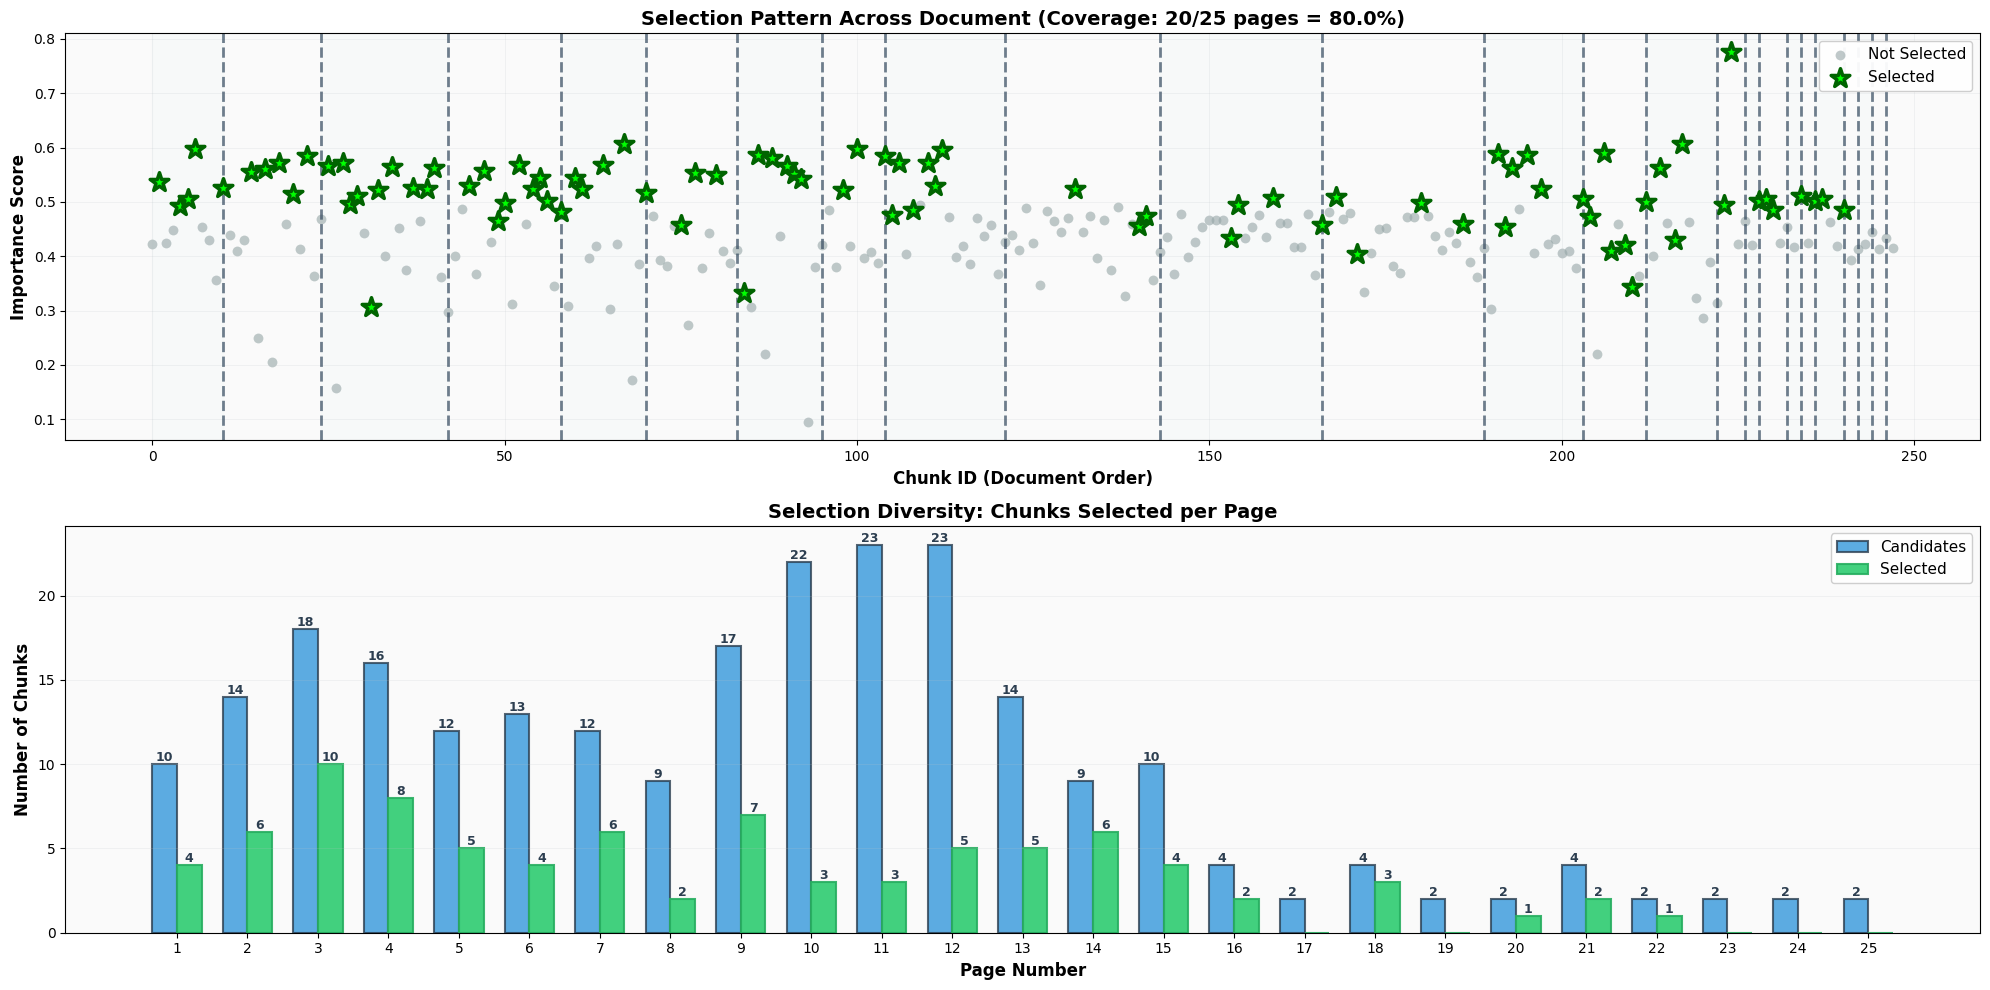


=== Selection Diversity Statistics ===
Total pages in document: 25
Pages with selected chunks: 20
Page coverage: 80.0%
Average chunks selected per page: 4.35

Pages with most selections:
  Page 3: 10/18 chunks (55.6%)
  Page 4: 8/16 chunks (50.0%)
  Page 9: 7/17 chunks (41.2%)
  Page 2: 6/14 chunks (42.9%)
  Page 7: 6/12 chunks (50.0%)


In [28]:
# Enhanced Selection Pattern Visualization - Show Diversity
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# --- Plot 1: Selection Pattern with Page Boundaries ---
ax1 = axes[0]

# Sort units by document order
sorted_units = sorted(units, key=lambda u: (u.page, u.bbox[1], u.bbox[0]))
chunk_order = {u.id: idx for idx, u in enumerate(sorted_units)}

# Prepare data for candidates
all_chunk_ids = []
all_scores = []
all_pages = []
all_selected = []

for u in sorted_units:
    if u.id in {c.id for c in candidates}:
        chunk_id = chunk_order[u.id]
        score = rel_scores.get(u.id, 0)
        is_selected = u.id in {s.unit.id for s in selected}
        
        all_chunk_ids.append(chunk_id)
        all_scores.append(score)
        all_pages.append(u.page)
        all_selected.append(is_selected)

all_chunk_ids = np.array(all_chunk_ids)
all_scores = np.array(all_scores)
all_pages = np.array(all_pages)
all_selected = np.array(all_selected)

# Add page boundary lines
page_boundaries = []
current_page = all_pages[0] if len(all_pages) > 0 else 0
for i, page in enumerate(all_pages):
    if page != current_page:
        page_boundaries.append(i)
        current_page = page

# Alternate page shading with stronger colors
for i, boundary in enumerate(page_boundaries):
    start = page_boundaries[i-1] if i > 0 else 0
    end = boundary
    if i % 2 == 0:
        ax1.axvspan(all_chunk_ids[start], all_chunk_ids[end], alpha=0.15, color='#e8f4f8')

# Plot all chunks with dark color on white/light blue background
ax1.scatter(all_chunk_ids[~all_selected], all_scores[~all_selected],
           c='#95a5a6', s=50, alpha=0.6, marker='o', linewidths=0, label='Not Selected')

# Plot selected chunks with high-contrast vibrant color
ax1.scatter(all_chunk_ids[all_selected], all_scores[all_selected],
           c='#00ff00', s=200, alpha=1.0, marker='*',
           edgecolors='#006400', linewidths=2.5, label='Selected', zorder=10)

# Add page boundary lines
for boundary in page_boundaries:
    ax1.axvline(x=all_chunk_ids[boundary], color='#34495e', linestyle='--', 
               linewidth=2, alpha=0.7)

# Calculate coverage statistics
selected_pages = set(all_pages[all_selected])
total_pages = len(set(all_pages))
coverage_pct = 100 * len(selected_pages) / total_pages if total_pages > 0 else 0

ax1.set_xlabel('Chunk ID (Document Order)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Importance Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Selection Pattern Across Document (Coverage: {len(selected_pages)}/{total_pages} pages = {coverage_pct:.1f}%)',
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.95, fontsize=11)
ax1.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='#bdc3c7')
ax1.set_facecolor('#fafafa')  # Very light gray background

# --- Plot 2: Per-Page Coverage Heatmap ---
ax2 = axes[1]

# Calculate selections per page
pages_list = sorted(set(all_pages))
page_stats = []
for page in pages_list:
    page_mask = all_pages == page
    n_candidates = page_mask.sum()
    n_selected = (page_mask & all_selected).sum()
    page_stats.append({
        'page': page,
        'candidates': n_candidates,
        'selected': n_selected,
        'selection_rate': n_selected / n_candidates if n_candidates > 0 else 0
    })

pages = [s['page'] for s in page_stats]
selected_counts = [s['selected'] for s in page_stats]
candidate_counts = [s['candidates'] for s in page_stats]

# Create grouped bar chart with high contrast colors
x = np.arange(len(pages))
width = 0.35

bars1 = ax2.bar(x - width/2, candidate_counts, width, label='Candidates',
               color='#3498db', edgecolor='#2c3e50', linewidth=1.5, alpha=0.8)
bars2 = ax2.bar(x + width/2, selected_counts, width, label='Selected',
               color='#2ecc71', edgecolor='#27ae60', linewidth=1.5, alpha=0.9)

# Add value labels on bars with better visibility
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')

ax2.set_xlabel('Page Number', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Chunks', fontsize=12, fontweight='bold')
ax2.set_title('Selection Diversity: Chunks Selected per Page', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pages)
ax2.legend(loc='upper right', framealpha=0.95, fontsize=11)
ax2.grid(True, alpha=0.25, linestyle='-', axis='y', linewidth=0.5, color='#bdc3c7')
ax2.set_facecolor('#fafafa')  # Very light gray background

plt.tight_layout()
plt.show()

# Print diversity statistics
print(f"\n=== Selection Diversity Statistics ===")
print(f"Total pages in document: {total_pages}")
print(f"Pages with selected chunks: {len(selected_pages)}")
print(f"Page coverage: {coverage_pct:.1f}%")
print(f"Average chunks selected per page: {len(selected) / len(selected_pages):.2f}")
print(f"\nPages with most selections:")
top_pages = sorted(page_stats, key=lambda x: x['selected'], reverse=True)[:5]
for p in top_pages:
    print(f"  Page {p['page']}: {p['selected']}/{p['candidates']} chunks ({100*p['selection_rate']:.1f}%)")

## Stage 6.5: Diagnostic Visualizations
*Visualize selection results and budget usage*

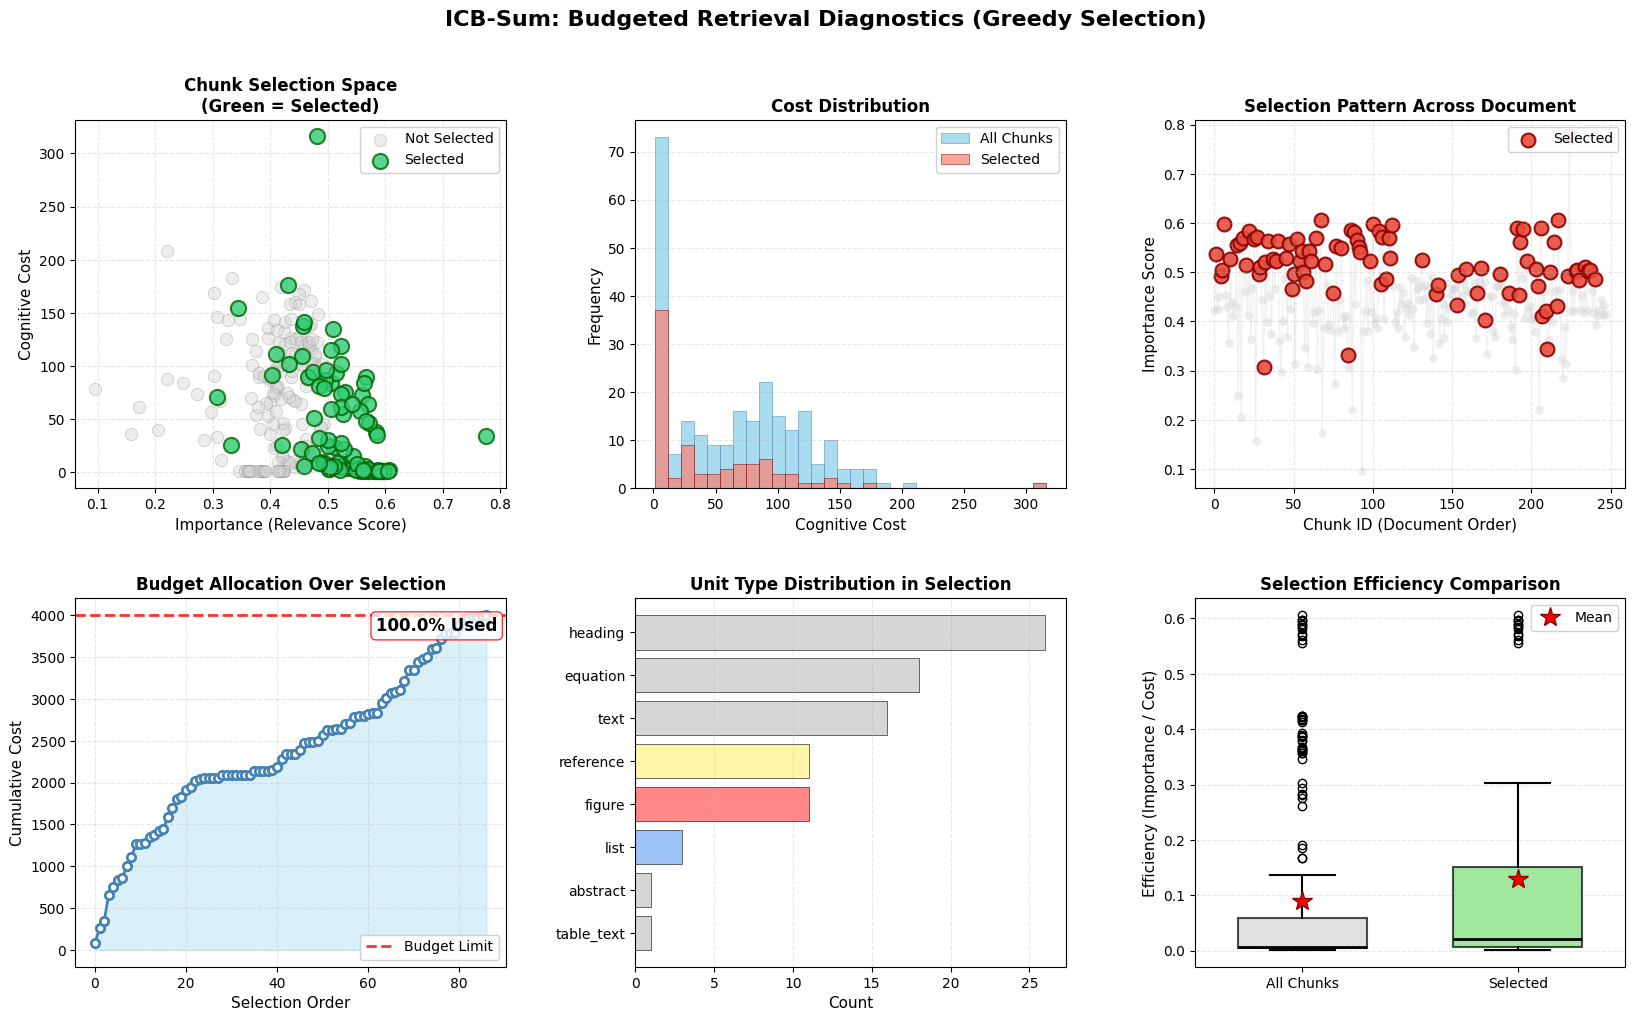


Diagnostics for 87 selected units
Budget used: 4000/4000 tokens


In [29]:
# Diagnostic Plots - Visualize selection results
import matplotlib.pyplot as plt
from src.diagnostics import RetrievalDiagnostics
from matplotlib.gridspec import GridSpec

# Create diagnostics instance (using greedy selection)
diagnostics = RetrievalDiagnostics(
    all_units=units,
    candidates=candidates,
    selected=selected,  # greedy selection
    costs=costs,
    rel_scores=rel_scores,
    budget_tokens=cfg.selection.budget_tokens,
)

# Create figure with custom layout
fig = plt.figure(figsize=(20, 11))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # Chunk Selection Space
ax2 = fig.add_subplot(gs[0, 1])  # Cost Distribution
ax3 = fig.add_subplot(gs[0, 2])  # Selection Pattern
ax4 = fig.add_subplot(gs[1, 0])  # Budget Allocation
ax5 = fig.add_subplot(gs[1, 1])  # Unit Type Distribution
ax6 = fig.add_subplot(gs[1, 2])  # Selection Efficiency

# Generate each plot
diagnostics._plot_selection_space(ax1)
diagnostics._plot_cost_distribution(ax2)
diagnostics._plot_selection_pattern(ax3)
diagnostics._plot_budget_allocation(ax4)
diagnostics._plot_unit_type_distribution(ax5)
diagnostics._plot_efficiency_comparison(ax6)

# Add main title
fig.suptitle('ICB-Sum: Budgeted Retrieval Diagnostics (Greedy Selection)',
            fontsize=16, fontweight='bold', y=0.98)

plt.show()

print(f"\nDiagnostics for {len(selected)} selected units")
print(f"Budget used: {sum(s.cost for s in selected)}/{cfg.selection.budget_tokens} tokens")

In [30]:
len(candidates)

248

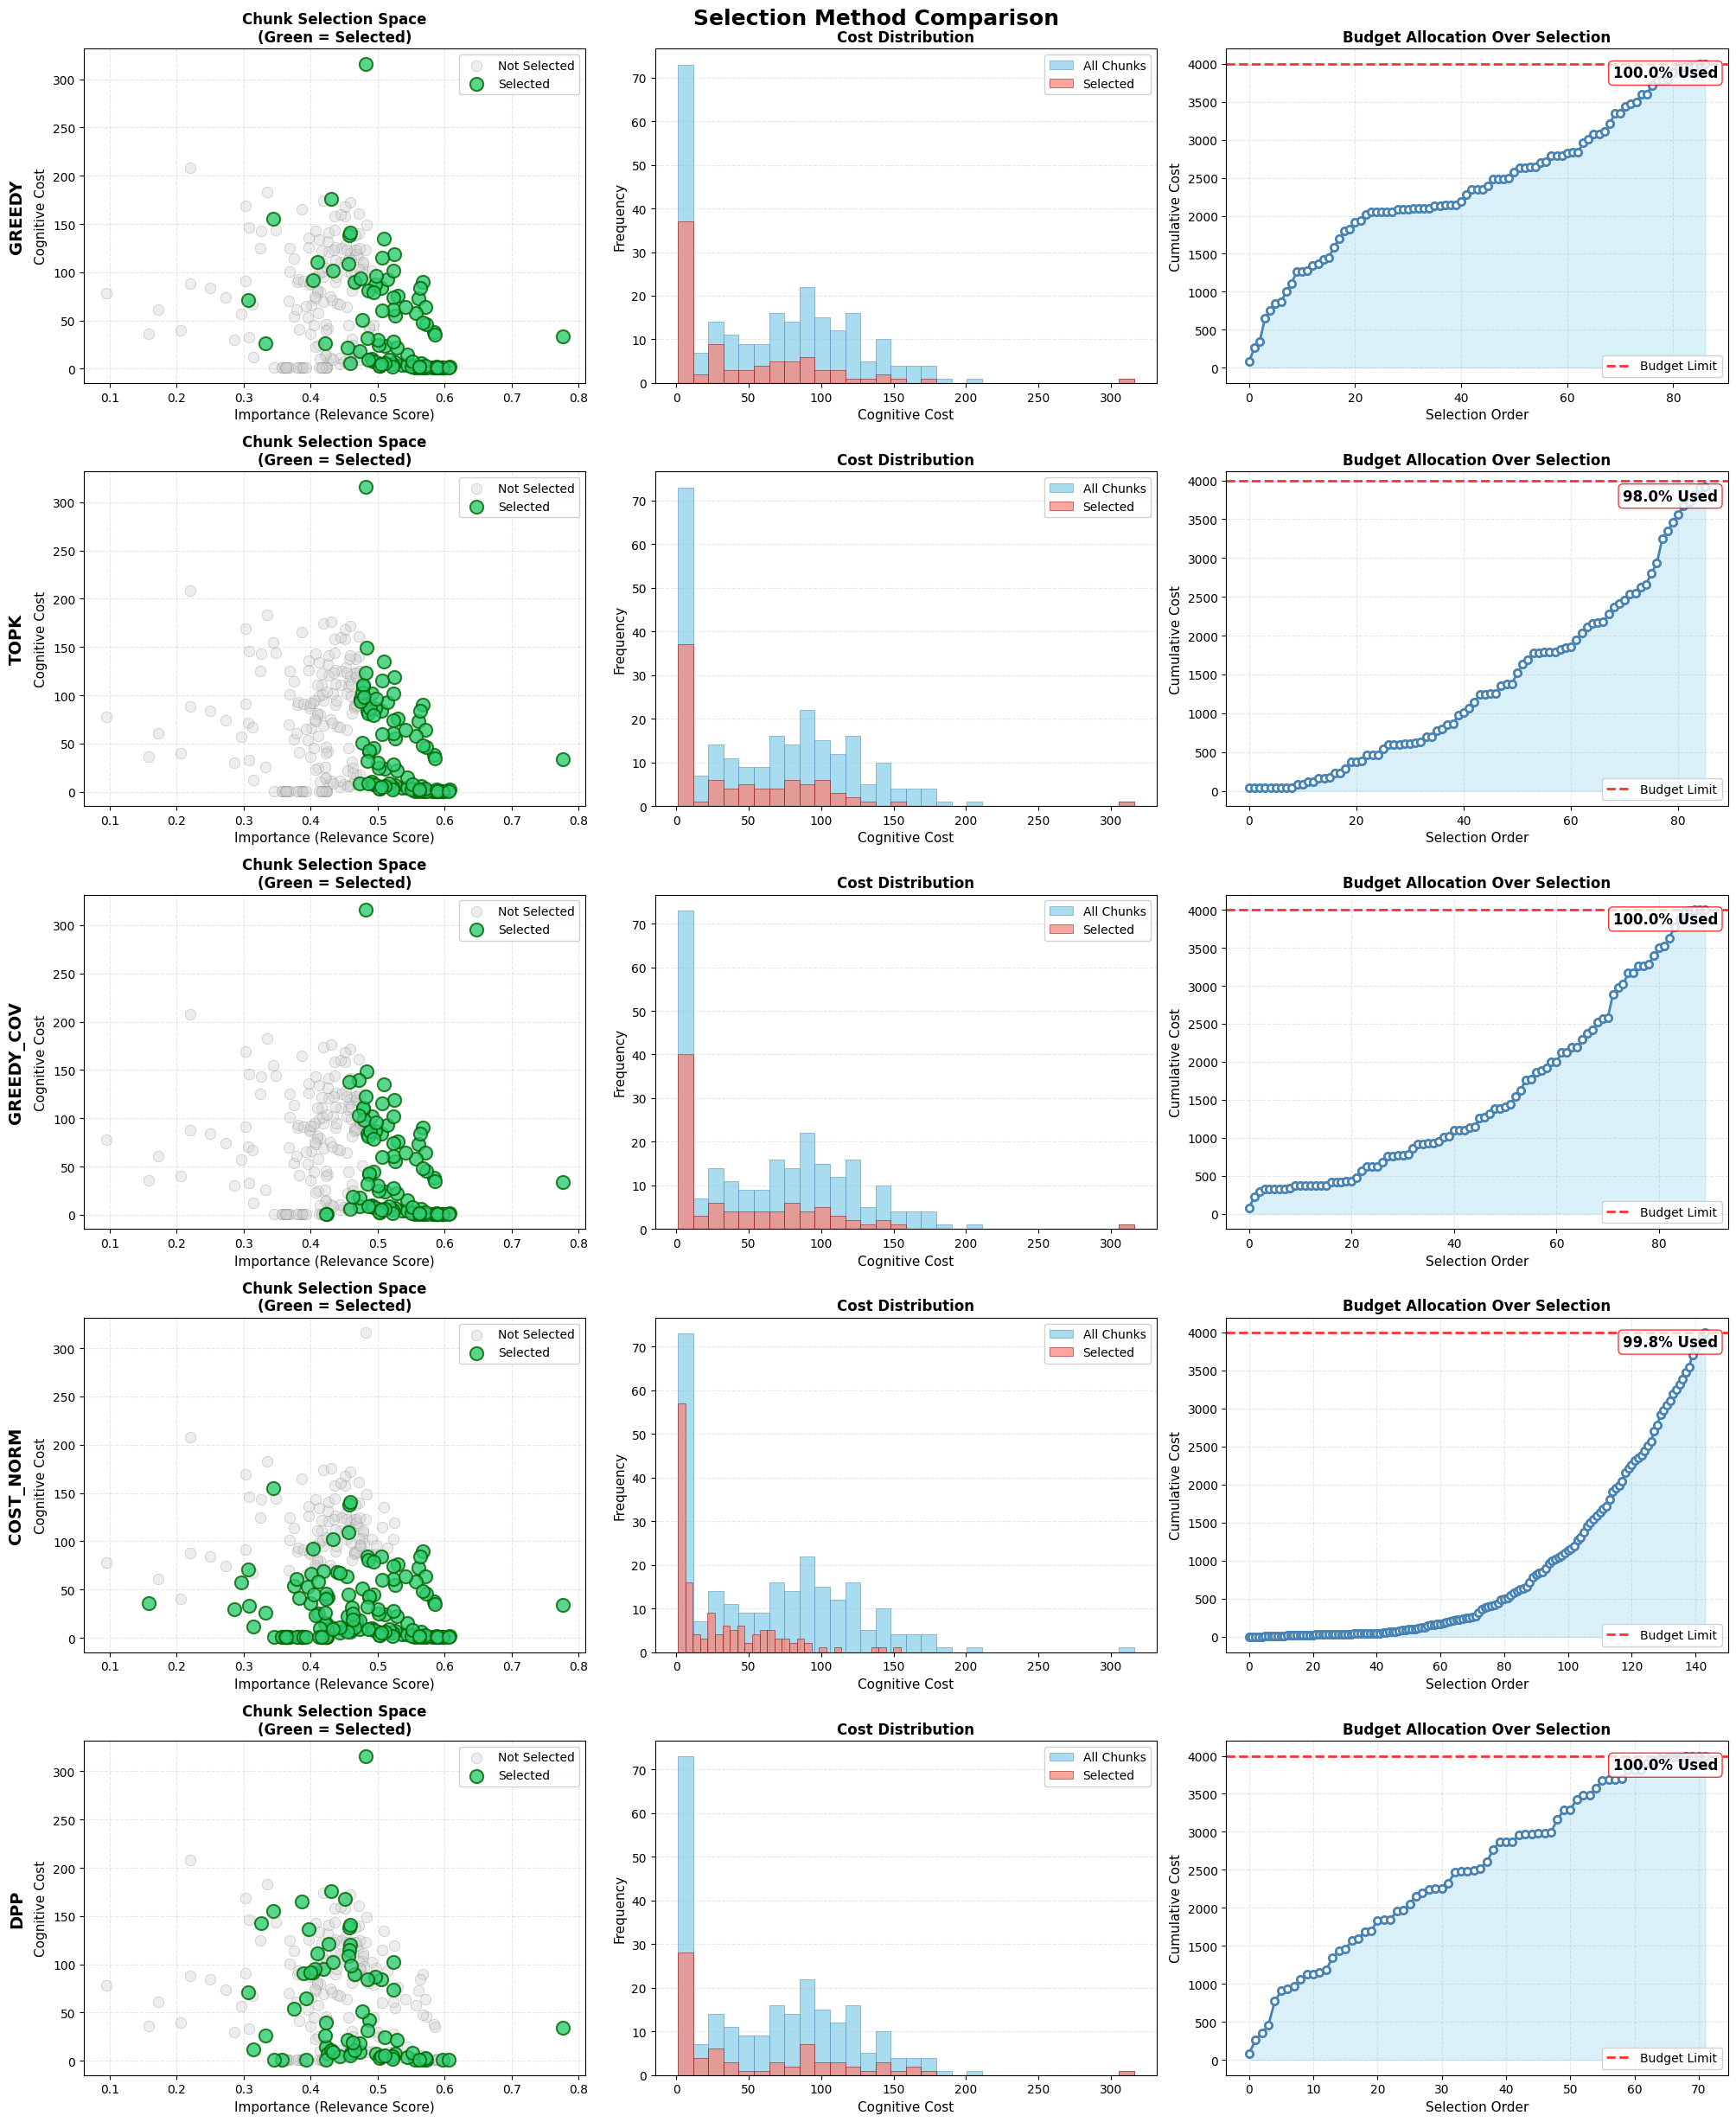

In [31]:
# Optional: Compare diagnostics across all selection methods
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
fig.suptitle('Selection Method Comparison', fontsize=18, fontweight='bold')

methods = ["greedy", "topk", "greedy_cov", "cost_norm", "dpp"]

for i, method in enumerate(methods):
    sel = selections[method]
    
    # Create diagnostics for this method
    diag = RetrievalDiagnostics(
        all_units=units,
        candidates=candidates,
        selected=sel,
        costs=costs,
        rel_scores=rel_scores,
        budget_tokens=cfg.selection.budget_tokens,
    )
    
    # Plot selection space, cost distribution, and budget allocation
    diag._plot_selection_space(axes[i, 0])
    diag._plot_cost_distribution(axes[i, 1])
    diag._plot_budget_allocation(axes[i, 2])
    
    # Add method label
    axes[i, 0].text(-0.15, 0.5, f'{method.upper()}',
                    transform=axes[i, 0].transAxes,
                    fontsize=14, fontweight='bold', rotation=90,
                    verticalalignment='center')

plt.tight_layout()
plt.show()

In [19]:
selected

[Selected(unit=EvidenceUnit(id='201d187a14cbfe36', page=8, bbox=(0.0, 0.0, 2550.0, 3300.0), type='text', retrieval_text='While diffusion models might resemble flows [9, 46, 10, 32, 5, 16, 23] and VAEs [33, 47, 37], diffusion models are designed so that \\(q\\) has no parameters and the top-level latent \\(\\mathbf{x}_T\\) has nearly zero mutual information with the data \\(\\mathbf{x}_0\\). Our \\(\\epsilon\\)-prediction reverse process parameterization establishes a connection between diffusion models and denoising score matching over multiple noise levels with annealed Langevin dynamics for sampling [55, 56]. Diffusion models, however, admit straightforward log likelihood evaluation, and the training procedure explicitly trains the Langevin dynamics sampler using variational inference (see Appendix C for details). The connection also has the implication that a certain weighted form of denoising score matching is the same as variational inference to train a Langevin-like sampler. Othe

## Stage 7: Summary Generation
*Generate structured summary from selected units*

In [ ]:
from src.anchor_summary import generate_anchor_summary

t0 = time.perf_counter()

selected_chunks = []
for s in selected:
    u = s.unit
    selected_chunks.append({
        "chunk_id": u.id,
        "content": {
            "text": u.context_text,
            "image_paths": [str(p) for p in u.image_paths],
        },
        "metadata": {
            "unit_type": u.type,
            "cognitive_cost": int(s.cost),
            "importance_score": rel_scores.get(u.id),
        },
    })

client = OpenAIChatClient(timeout_s=cfg.extract.timeout_s)
summary_text, summary_meta = generate_anchor_summary(
    client=client,
    model=cfg.openai.model,
    temperature=cfg.openai.temperature,
    user_instruction=user_instruction,
    required_sections=cfg.summarization.required_sections,
    selected_chunks=selected_chunks,
    max_chars_per_chunk=cfg.summarization.max_chars_per_chunk,
)

print(f"Summary generated in {time.perf_counter() - t0:.1f}s")
print(f"\n{summary_text}")

## Save Outputs

In [ ]:
from src.diagnostics import generate_diagnostics
from src.pdf_highlighter import highlight_pdf
from src.utils import write_json

# Save summary
(out_dir / "summary.md").write_text(summary_text, encoding="utf-8")

# Generate diagnostics
generate_diagnostics(
    all_units=units,
    candidates=candidates,
    selected=selected,
    costs=costs,
    rel_scores=rel_scores,
    budget_tokens=cfg.selection.budget_tokens,
    output_path=out_dir / "diagnostics.png",
)

# Highlight PDF
if cfg.output.save_highlighted_pdf:
    highlight_pdf(pdf_path, [s.unit for s in selected], out_dir / "highlighted.pdf")

# Save context JSON
if cfg.output.save_context_json:
    for method, sel in selections.items():
        context_data = {
            "run_id": run_id,
            "pdf_path": str(pdf_path),
            "query": query,
            "method": method,
            "selected": [
                {
                    "chunk_id": s.unit.id,
                    "page": s.unit.page,
                    "type": s.unit.type,
                    "rel": float(rel_scores.get(s.unit.id, 0.0)),
                    "cost": int(s.cost),
                }
                for s in sel
            ],
            "budgets": {"total": cfg.selection.budget_tokens, "used": budgets_used[method]},
        }
        write_json(out_dir / f"context_{method}.json", context_data)

print(f"\nOutputs saved to: {out_dir}")